In [1]:
import os
import operator
from typing import TypedDict, Annotated, List
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from exa_py import Exa

load_dotenv()

# LLM 및 Exa 초기화
outline_llm = ChatOpenAI(model="gpt-4o-mini", temperature=1)
writer_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
exa = Exa(api_key=os.environ.get("EXA_API_KEY"))

c:\Users\shdnc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [14]:
# State 정의
class ReportState(TypedDict):
    topic: str                                          # 보고서 주제
    outline: str                                        # 개요
    
    # 각 섹션별 내용
    intro_content: str
    body1_content: str
    body2_content: str
    body3_content: str
    conclusion_content: str
    
    final_report: str  

In [15]:
from langchain_core.tools import tool

@tool
def web_search(
    query: str, 
    num_results: int = 3,
    search_type: str = "neural",      # "neural" (시맨틱), "keyword", "auto"
    max_characters: int = 3000,        # 텍스트 최대 길이
) -> str:
    """
    Exa를 사용한 웹 검색
    
    Args:
        query: 검색 쿼리
        num_results: 반환할 결과 수
        search_type: 검색 유형 (neural=시맨틱/keyword=키워드/auto=자동선택)
        max_characters: 텍스트 최대 문자 수
    """
    try:
        # 검색 파라미터 구성 (단순화)
        search_params = {
            "query": query,
            "type": search_type,
            "num_results": num_results,
            "text": {"max_characters": max_characters},
            "highlights": True # 하이라이트 기본 활성화
        }
        
        results = exa.search_and_contents(**search_params)
        
        search_results = []
        for result in results.results:
            # 기본 정보 구성
            result_text = f"📌 제목: {result.title}\n"
            result_text += f"🔗 URL: {result.url}\n"
            
            # 발행일 정보 (있는 경우)
            if hasattr(result, 'published_date') and result.published_date:
                result_text += f"📅 발행일: {result.published_date}\n"
            
            # 하이라이트 (핵심 문장들)
            if hasattr(result, 'highlights') and result.highlights:
                result_text += "\n💡 핵심 내용:\n"
                for i, highlight in enumerate(result.highlights, 1):
                    result_text += f"  {i}. {highlight.strip()}\n"
            
            # 본문 텍스트
            if hasattr(result, 'text') and result.text:
                text_preview = result.text[:max_characters]
                if len(result.text) > max_characters:
                    text_preview += "..."
                result_text += f"\n📄 본문:\n{text_preview}"
            
            search_results.append(result_text)
        
        # 검색 메타 정보 추가
        header = f"🔍 검색어: \"{query}\" | 결과: {len(results.results)}건\n"
        header += "=" * 60 + "\n\n"
        
        return header + "\n\n---\n\n".join(search_results)
        
    except Exception as e:
        return f"검색 실패: {str(e)}"

In [ ]:
pip install -U pydantic langchain

In [16]:
# 노드 함수들
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware


class OutlineStructure(BaseModel):
    """보고서 개요 구조"""
    서론: str = Field(description="서론에서 다룰 내용")
    본론1: str = Field(description="본론1에서 다룰 내용")
    본론2: str = Field(description="본론2에서 다룰 내용")
    본론3: str = Field(description="본론3에서 다룰 내용")
    결론: str = Field(description="결론에서 다룰 내용")

def create_outline(state: ReportState) -> ReportState:
    """주제에 대해 웹 검색 후 개요 작성"""
    topic = state["topic"]
    
    # 에이전트 생성 (웹 검색 도구 포함, structured output 강제)
    tools = [web_search]
    outline_agent = create_agent(
        outline_llm, 
        tools,
        response_format=OutlineStructure
    )
    
    # 개요 생성 요청
    prompt = f"""
주제: {topic}

위 주제에 대해 보고서 개요를 작성해주세요.

**중요: 최신 정보와 트렌드를 파악하기 위해 반드시 웹 검색을 먼저 수행하세요.**

검색 결과를 바탕으로 다음 구조로 개요를 작성해주세요:
1. 서론
2. 본론1
3. 본론2
4. 본론3
5. 결론

각 섹션에서 다룰 내용을 간략히 설명해주세요.
"""
    
    result = outline_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    
    return {
        "outline": result["messages"][-1].content
    }
def _write_section_common(state: ReportState, section_name: str) -> str:
    """공통 섹션 작성 로직"""
    topic = state["topic"]
    outline = state["outline"]
    
    # 에이전트 생성 (웹 검색 도구 포함 및 검색 횟수 제한 미들웨어 추가)
    tools = [web_search]
    section_agent = create_agent(
        writer_llm, 
        tools,
        middleware=[
            ToolCallLimitMiddleware(
                tool_name="web_search",
                run_limit=3
            )
        ]
    )
    
    prompt = f"""
보고서 주제: {topic}

전체 개요:
{outline}

현재 작성할 섹션: {section_name}

**중요: 해당 섹션에 대한 상세 정보를 얻기 위해 필요한 만큼 웹 검색을 수행하세요.**

검색 옵션 (우선 사용):
- query: "{topic} {section_name} 상세 내용"
- num_results: 3
- use_highlights: True
- max_characters: 3000
- livecrawl: "fallback"

필요하다면 여러 번 검색하여 충분한 정보를 수집한 후, 검색 결과를 바탕으로 위 섹션의 내용을 상세하게 작성해주세요. 
- 명확하고 논리적인 문장으로 작성
- 적절한 소제목 사용 가능
- 3000자 분량
"""
    result = section_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    return result["messages"][-1].content


In [17]:
def write_intro(state: ReportState) -> dict:
    content = _write_section_common(state, "서론")
    return {"intro_content": content}

def write_body1(state: ReportState) -> dict:
    content = _write_section_common(state, "본론1")
    return {"body1_content": content}

def write_body2(state: ReportState) -> dict:
    content = _write_section_common(state, "본론2")
    return {"body2_content": content}

def write_body3(state: ReportState) -> dict:
    content = _write_section_common(state, "본론3")
    return {"body3_content": content}

def write_conclusion(state: ReportState) -> dict:
    content = _write_section_common(state, "결론")
    return {"conclusion_content": content}


def compile_report(state: ReportState) -> ReportState:
    """모든 섹션을 통합하여 최종 보고서 생성"""
    topic = state["topic"]
    
    report_parts = [f"# {topic}\n"]
    
    sections = [
        ("서론", state.get("intro_content", "")),
        ("본론1", state.get("body1_content", "")),
        ("본론2", state.get("body2_content", "")),
        ("본론3", state.get("body3_content", "")),
        ("결론", state.get("conclusion_content", ""))
    ]
    
    for title, content in sections:
        report_parts.append(f"\n## {title}\n{content}\n")
    
    final_report = "\n".join(report_parts)
    
    return {"final_report": final_report}


In [18]:
# 그래프 빌드
workflow = StateGraph(ReportState)

# 노드 추가
workflow.add_node("create_outline", create_outline)
workflow.add_node("write_intro", write_intro)
workflow.add_node("write_body1", write_body1)
workflow.add_node("write_body2", write_body2)
workflow.add_node("write_body3", write_body3)
workflow.add_node("write_conclusion", write_conclusion)
workflow.add_node("compile_report", compile_report)

# 엣지 연결
workflow.add_edge(START, "create_outline")

# 정적 병렬 연결 (Fan-out)
workflow.add_edge("create_outline", "write_intro")
workflow.add_edge("create_outline", "write_body1")
workflow.add_edge("create_outline", "write_body2")
workflow.add_edge("create_outline", "write_body3")
workflow.add_edge("create_outline", "write_conclusion")

# 통합 노드로 연결 (Fan-in)
workflow.add_edge("write_intro", "compile_report")
workflow.add_edge("write_body1", "compile_report")
workflow.add_edge("write_body2", "compile_report")
workflow.add_edge("write_body3", "compile_report")
workflow.add_edge("write_conclusion", "compile_report")

workflow.add_edge("compile_report", END)

# 컴파일
graph = workflow.compile()


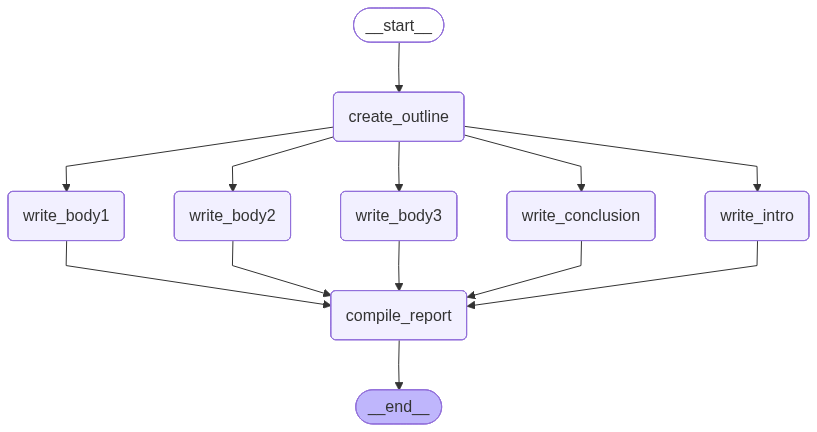

In [19]:
# 그래프 시각화
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
inputs = {
    "topic": "Economic Order Quantity (EOQ) Model에 대한 분석"
}
for chunk in graph.stream(
    inputs,
    # Set subgraphs=True to stream outputs from subgraphs
    subgraphs=True,  
    stream_mode="updates",
):
    print(chunk)

(('create_outline:d46bcee6-4d7a-fc14-812a-38baa895f7bd',), {'model': {'messages': [AIMessage(content='', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 575, 'total_tokens': 613, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DQzpk8JsK0qSubhGBESUMJNm3p061', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d59b5-ed97-7392-b92b-09eb5a713140-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'Economic Order Quantity EOQ model analysis', 'num_results': 5, 'search_type': 'neural', 'max_characters': 3000}, 'id': 'call_mJg8o7zGNu1eYwnx9VwyfYJk', 'type': 'tool_call'}], invalid_tool_calls=

In [21]:
inputs = {"topic": "Economic Order Quantity (EOQ) Model에 대한 분석"}
print(f"🚀 보고서 작성을 시작합니다: '{inputs['topic']}'\n")

last_node = None
final_report = "" 

for chunk in graph.stream(inputs, subgraphs=True, stream_mode="updates"):
    namespace, update = chunk
    
    if not namespace:
        # 구조 1: update['final_report'] 직접 존재
        if 'final_report' in update:
            final_report = update['final_report']
        # 구조 2: update['compile_report']['final_report'] 형태로 존재 (노드 이름으로 감싸진 경우)
        else:
            for node_data in update.values():
                if isinstance(node_data, dict) and 'final_report' in node_data:
                    final_report = node_data['final_report']
        continue
        
    node_name = namespace[-1]
    clean_name = node_name.split(':')[0] if ':' in node_name else node_name

    if clean_name != last_node:
        print(f"\n{'='*40}")
        print(f"🔄 단계: {clean_name}")
        print(f"{'='*40}")
        last_node = clean_name

    # 도구 및 모델 진행 상황 출력
    if 'tools' in update:
        msgs = update['tools'].get('messages', [])
        if msgs:
            content = getattr(msgs[0], 'content', "")
            header = content.split('\n')[0] if content else "검색 완료"
            print(f"  🔍 {header}")
            
    elif 'model' in update:
        msgs = update['model'].get('messages', [])
        if msgs:
            msg_content = getattr(msgs[0], 'content', "")
            if msg_content:
                print(f"  📝 생성 중: {msg_content[:100]}...")

    # 섹션 완료 상태 출력
    if isinstance(update, dict):
        for key in update:
            if key.endswith('_content'):
                print(f"  ✅ {key.replace('_content','')} 작성 완료")

# --- 최종 결과 출력 및 저장 ---
print("\n" + "="*50)
if final_report:
    print("✨ 보고서 작성이 최종 완료되었습니다!")
    
    file_name = f"report_{inputs['topic'].replace(' ', '_')}.md"
    with open(file_name, "w", encoding="utf-8") as f:
        f.write(final_report)
    
    print(f"💾 파일 저장 완료: {file_name}")
    print(f"\n[보고서 미리보기]\n{'-'*20}\n{final_report[:500]}...")
else:
    print("❌ 스트리밍이 끝났으나 'final_report'를 수집하지 못했습니다.")
    print("그래프의 마지막 노드에서 'final_report' 키를 반환하는지 확인해 주세요.")

🚀 보고서 작성을 시작합니다: 'Economic Order Quantity (EOQ) Model에 대한 분석'


🔄 단계: create_outline
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model analysis" | 결과: 5건
  📝 생성 중: {"서론":"경제적 주문량(Economic Order Quantity, EOQ) 모델의 필요성 및 발전 배경을 소개하고, 이 모델이 재고 관리에서 어떻게 활용되는지를 설명한다.",...

🔄 단계: write_body3

🔄 단계: write_conclusion

🔄 단계: write_intro

🔄 단계: write_body2

🔄 단계: write_body1

🔄 단계: write_body3
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model에 대한 분석 본론3 상세 내용" | 결과: 3건

🔄 단계: write_conclusion
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model에 대한 분석 결론 상세 내용" | 결과: 3건

🔄 단계: write_body1
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model에 대한 분석 본론1 상세 내용" | 결과: 3건

🔄 단계: write_intro
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model에 대한 분석 서론 상세 내용" | 결과: 3건

🔄 단계: write_body2
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model에 대한 분석 본론2 상세 내용" | 결과: 3건
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model cost analysis" | 결과: 3건
  🔍 🔍 검색어: "Economic Order Quantity (EOQ) Model application and limitations" | 결과: 3건

🔄 

In [22]:
from IPython.display import display, Markdown
display(Markdown("""
# Economic Order Quantity (EOQ) Model에 대한 분석


## 서론
## 서론: 경제적 주문량(Economic Order Quantity, EOQ) 모델의 필요성과 발전 배경

현대의 기업 운영에서 재고 관리의 중요성은 날로 증가하고 있으며, 이는 기업의 비용 절감과 운영 효율성 향상에 직결된다. 이러한 맥락에서 경제적 주문량(Economic Order Quantity, EOQ) 모델은 재고 관리의 핵심 도구로 자리잡고 있다. EOQ 모델은 기업이 재고를 최적화하고 관련 비용을 최소화하기 위해 필요한 주문량을 계산하는 기법으로, 20세기 초 Ford Whitman Harris에 의해 처음 개발되었다. 이 모델은 재고 관리의 이론적 기초를 제공하며, 실제 기업 운영에서도 널리 활용되고 있다.

### EOQ 모델의 정의 및 기능

EOQ 모델은 특정 상품의 연간 수요량, 주문 비용, 유지 비용을 바탕으로 최적의 주문량을 결정하는 수학적 공식이다. 이 모델의 주된 목적은 주문 비용과 재고 유지 비용 간의 균형을 맞추어 총 비용을 최소화하는 것이다. 주문 비용은 주문을 처리하는 과정에서 발생하는 모든 비용을 포함하며, 재고 유지 비용은 재고를 보관하는 데 드는 비용을 의미한다. 따라서 EOQ 모델은 기업이 얼마나 자주, 얼마나 많은 양을 주문해야 하는지를 결정하는 데 도움을 준다.

### EOQ 모델의 발전 배경

EOQ 모델은 1900년대 초반에 처음 제안된 이후, 다양한 산업 분야에서 응용되며 발전해왔다. 초기에는 단순한 수학적 모델로 시작했지만, 시간이 지남에 따라 기업의 복잡한 환경을 반영하기 위해 다양한 변형 및 확장 모델이 개발되었다. 예를 들어, 수요가 변동하는 경우, 재고 부족 비용을 고려하는 경우, 그리고 대량 구매 할인과 같은 요소를 포함하는 모델들이 추가적으로 제안되었다. 이러한 발전은 EOQ 모델이 단순한 계산 도구를 넘어, 기업의 전략적 의사결정에 필수적인 요소로 자리잡는 데 기여하였다.

### EOQ 모델의 필요성

오늘날의 경쟁이 치열한 시장 환경에서 기업들은 비용 절감과 효율성을 극대화해야 한다. EOQ 모델은 이러한 필요를 충족시키기 위한 효과적인 방법으로, 재고 관리의 최적화를 통해 기업의 전반적인 운영 효율성을 향상시킬 수 있다. 특히, 재고 유지 비용과 주문 비용을 균형 있게 관리함으로써 기업은 자본을 보다 효율적으로 활용할 수 있으며, 이는 궁극적으로 수익성 향상으로 이어진다.

결론적으로, EOQ 모델은 재고 관리 분야에서 필수적인 도구로 자리잡고 있으며, 기업이 운영 효율성을 높이고 비용을 절감하는 데 기여하는 중요한 역할을 하고 있다. 다음 섹션에서는 EOQ 모델의 기본 개념과 수식을 살펴보며, 이 모델이 사용되는 가정과 제약 사항에 대해 논의할 것이다.


## 본론1
## 본론 1: Economic Order Quantity (EOQ) 모델의 기본 개념과 수식

### 1. EOQ의 정의와 필요성
경제적 주문량(Economic Order Quantity, EOQ) 모델은 기업이 재고를 관리하는 데 있어 최적의 주문량을 결정하기 위한 수학적 모델입니다. 이 모델은 주문 비용과 재고 유지 비용을 최소화하면서 기업의 운영 효율성을 극대화하는 데 기여합니다. EOQ는 단순히 재고를 쌓아두는 것이 아니라, 재고 관리의 전략적 도구로서 기업이 필요로 하는 재고 수준을 적절히 유지할 수 있도록 도와줍니다. 

### 2. EOQ의 기본 가정
EOQ 모델은 몇 가지 기본 가정을 바탕으로 설정됩니다:
1. **수요와 주문 비용의 일정성**: EOQ는 특정 상품의 연간 수요량, 주문 원가, 유지 비용이 일정하다는 가정을 전제로 합니다.
2. **재고 부족 없음**: 재고가 부족해 발생하는 추가 비용은 고려하지 않으며, 적시에 주문이 이루어진다고 가정합니다.
3. **단위 매입가격 일정**: 주문량에 따른 가격 변화(예: 대량 구매 할인)는 고려하지 않습니다.

이러한 가정들은 현실 세계에서는 다소 제한적일 수 있지만, EOQ를 통해 재고 관리의 큰 틀을 잡는 데 유용합니다.

### 3. EOQ 계산 공식
EOQ를 계산하기 위해 다음의 수식을 사용합니다:

\[
EOQ = \sqrt{\frac{2DS}{H}}
\]

여기서,
- \(D\): 연간 총 수요량
- \(S\): 1회 주문 시 발생하는 고정비용(주문 비용)
- \(H\): 단위당 연간 재고 유지 비용

이 공식은 주문 비용과 재고 유지 비용을 모두 고려하여 최적의 주문량을 산출합니다.

### 4. 주문 비용과 재고 유지 비용의 산출 방법
EOQ 계산에서 1회 주문당 발생하는 비용(주문비용)과 단위당 연간 재고 유지 비용은 가장 중요한 변수입니다. 이 두 요소를 정확히 산출해야 EOQ의 계산 결과가 현실적이고 신뢰할 수 있습니다.

- **주문 비용 (F)**: 주문을 처리하는 과정에서 발생하는 모든 고정 비용을 포함합니다. 예를 들어, 주문 준비 비용, 서류 및 행정 처리 비용, 배송비, 품질 확인 및 인수 비용 등이 있습니다.
  
- **재고 유지 비용 (C)**: 특정 품목을 1년 동안 보관하는 데 드는 비용으로, 주로 재고를 보관하는 창고 및 관리와 관련된 비용으로 구성됩니다. 창고 임대료, 재고 취급비, 보험료, 재고 감모 및 폐기 손실 등이 포함됩니다.

### 5. EOQ의 실제 적용
EOQ는 다양한 산업에서 활용됩니다. 예를 들어, 제조업체는 생산 계획을 수립하는 데 EOQ를 사용하여 재고 수준을 최적화하고, 유통업체는 고객 수요에 맞춰 적정 재고를 유지하는 데 활용합니다. EOQ 모델은 재고 부족 위험을 줄이고, 운영 효율성을 증대시키며, 재고 유지비용과 주문비용을 최소화하는 데 기여합니다.

### 6. 결론
EOQ 모델은 단순한 수학적 계산이 아니라, 기업의 자금 흐름과 운영 효율성을 좌우하는 핵심 전략입니다. EOQ를 통해 기업은 재고 비용을 줄이고 공급망의 안정성을 높일 수 있습니다. 다양한 변형 모델과 ERP 시스템 연계 등을 통해 EOQ의 활용 폭은 더욱 넓어지고 있으며, 앞으로도 중요한 재고관리 도구로 자리잡을 것입니다.


## 본론2
## 본론 2: EOQ 모델의 연관 비용 요소 분석

### 1. EOQ 모델의 기본 개념

경제적 주문량(Economic Order Quantity, EOQ) 모델은 재고 관리에서 주문 비용과 재고 유지 비용을 최소화하기 위해 최적의 주문량을 계산하는 기법입니다. EOQ는 재고 관리의 효율성을 높이기 위해 주문 비용과 재고 유지 비용 간의 균형을 맞추는 것을 목표로 하며, 이를 통해 기업은 운영 비용을 절감하고 자본 회전율을 향상시킬 수 있습니다.

### 2. 비용 요소의 정의

EOQ 모델에서 고려되는 주요 비용 요소는 다음과 같습니다:

- **주문 비용(Ordering Cost)**: 특정 상품을 주문하는 과정에서 발생하는 비용으로, 주문을 처리하기 위한 인건비, 서류 처리비, 배송비 등이 포함됩니다. 이 비용은 주문 횟수에 비례하여 증가합니다.
  
- **재고 유지 비용(Holding Cost)**: 재고를 보관하는 데 필요한 비용으로, 창고 임대료, 보험료, 재고 손실 비용 등이 포함됩니다. 이 비용은 보유하는 재고량에 비례하여 증가합니다.

- **총 비용(Total Cost)**: 총 비용은 주문 비용과 재고 유지 비용의 합으로, EOQ 모델의 목표는 이 총 비용을 최소화하는 것입니다.

### 3. EOQ 모델의 수식 유도

EOQ 모델의 기본 수식은 다음과 같이 표현됩니다:

\[
EOQ = \sqrt{\frac{2DS}{H}}
\]

여기서,
- \(D\)는 연간 수요량,
- \(S\)는 주문당 비용,
- \(H\)는 단위당 연간 재고 유지 비용입니다.

이 수식은 주문 비용과 재고 유지 비용을 모두 고려하여 최적의 주문량을 산출하는 데 사용됩니다.

### 4. 비용 요소의 분석

#### 4.1 주문 비용의 분석

주문 비용은 일반적으로 고정비용으로 간주되며, 주문 횟수에 따라 변동합니다. 주문 비용의 주요 구성 요소는 다음과 같습니다:

- **주문 준비 비용**: 주문을 처리하기 위해 필요한 인력 및 시간 비용
- **서류 처리 비용**: 발주서 작성 및 송부에 드는 비용
- **배송비**: 물품의 운송 비용
- **품질 검사 비용**: 물품 수령 후 품질 확인을 위한 인력 비용

이러한 비용들은 각각의 기업 환경에 따라 상이하므로, 정확한 계산이 필요합니다.

#### 4.2 재고 유지 비용의 분석

재고 유지 비용은 재고를 보관하는 데 드는 비용으로, 다음과 같은 요소로 구성됩니다:

- **창고 임대료**: 재고를 보관하기 위한 공간의 임대 비용
- **재고 취급비**: 물품의 적재 및 이동에 필요한 비용
- **보험료**: 화재, 도난 등의 위험을 보장하기 위한 비용
- **폐기 손실 비용**: 유통기한이 있는 상품의 경우 발생할 수 있는 손실 비용

이러한 비용은 재고량에 비례하므로, 재고를 얼마나 보유할 것인지에 대한 결정이 중요합니다.

### 5. EOQ 모델의 적용 사례

EOQ 모델은 다양한 산업에서 효율적인 재고 관리 도구로 사용됩니다. 예를 들어, 제조업체는 EOQ를 통해 원자재의 주문량을 최적화하여 생산 비용을 절감할 수 있습니다. 소매업체는 EOQ를 활용하여 고객 수요에 맞춘 재고를 유지하고, 과잉 재고로 인한 손실을 줄일 수 있습니다.

### 6. EOQ 모델의 한계

EOQ 모델은 몇 가지 가정을 기반으로 하므로, 실제 환경에서는 한계가 존재합니다. 예를 들어, 수요가 일정하다는 가정은 현실에서 자주 변동할 수 있으며, 주문 비용과 재고 유지 비용이 일정하다는 가정도 실제 상황에서는 변동성이 클 수 있습니다. 또한, 대량 구매 시 할인 등의 요소를 고려하지 않기 때문에, 이러한 요소들을 반영하기 위해서는 추가적인 조정이 필요합니다.

### 결론

EOQ 모델은 재고 관리에서 비용 효율성을 높이는 데 중요한 도구입니다. 주문 비용과 재고 유지 비용을 분석하고 최적의 주문량을 계산함으로써, 기업은 운영 효율성을 극대화할 수 있습니다. 그러나 EOQ 모델의 가정과 한계를 이해하고, 실제 비즈니스 환경에 맞게 조정하는 것이 중요합니다.


## 본론3
## 본론3: EOQ 모델의 실제 적용 사례

### 1. EOQ 모델의 개념과 기본 가정

경제적 주문량(Economic Order Quantity, EOQ) 모델은 기업이 재고를 관리하는 데 있어 주문 비용과 재고 유지 비용을 최소화하기 위한 최적의 주문량을 계산하는 기법입니다. EOQ는 다음과 같은 기본 가정을 전제로 합니다:

1. **수요의 일정성**: 특정 품목의 연간 수요량이 일정하다고 가정합니다.
2. **주문비용과 재고유지비용의 일정성**: 주문 비용과 재고 유지 비용이 일정하다고 가정합니다.
3. **재고 부족 없음**: 주문이 적시에 이루어져 재고가 부족하지 않다고 가정합니다.
4. **단위 매입 가격 일정**: 구매량에 따른 가격 변화는 고려하지 않습니다.

이러한 가정들은 EOQ 모델이 현실 세계에서 적용될 때의 한계를 나타내기도 하지만, 기본적인 재고 관리 원칙을 이해하는 데 유용합니다.

### 2. EOQ 모델의 적용 사례

#### 2.1. 소매업체의 EOQ 적용 사례

한 소매업체에서 주류를 판매한다고 가정해 봅시다. 이 업체는 매년 10,000병의 와인을 판매하고, 1회 주문당 비용이 5,000원, 단위당 연간 재고 유지 비용이 2,000원이라고 가정합니다. EOQ 모델을 사용하여 최적의 주문량을 계산하면 다음과 같습니다.

\[
EOQ = \sqrt{\frac{2DS}{H}} = \sqrt{\frac{2 \times 10000 \times 5000}{2000}} = 158.11
\]

따라서, 이 소매업체는 매번 약 158병의 와인을 주문하는 것이 가장 경제적입니다. 이러한 주문량을 유지함으로써 주문 비용과 재고 유지 비용을 최소화할 수 있습니다.

#### 2.2. 제조업체의 EOQ 적용 사례

제조업체의 경우, 원자재를 구매하는 데 EOQ 모델을 적용할 수 있습니다. 예를 들어, 한 제조업체가 연간 50,000kg의 원자재를 필요로 하고, 1회 주문당 비용이 10,000원, 단위당 연간 재고 유지 비용이 500원이라고 가정합니다. EOQ를 계산하면:

\[
EOQ = \sqrt{\frac{2DS}{H}} = \sqrt{\frac{2 \times 50000 \times 10000}{500}} = 447.21
\]

이 제조업체는 매번 약 447kg의 원자재를 주문하는 것이 최적입니다. 이를 통해 재고 비용을 줄이고, 생산 효율성을 높일 수 있습니다.

### 3. EOQ 모델의 한계

EOQ 모델은 여러 산업에서 유용하게 사용되지만, 몇 가지 한계가 있습니다:

1. **수요의 변동성**: 실제로는 수요가 계절에 따라 변동할 수 있으며, EOQ 모델은 이러한 변동성을 반영하지 않습니다.
2. **주문 리드 타임**: EOQ 모델은 주문이 즉시 이루어질 것이라고 가정하지만, 실제로는 주문 후 일정 기간이 소요될 수 있습니다.
3. **변동 비용**: 대량 구매에 따른 할인이나 가격 변동은 EOQ 모델에서 고려되지 않습니다.

이러한 한계에도 불구하고 EOQ 모델은 재고 관리에서 기본적인 원칙을 제공하며, 많은 기업들이 이를 통해 운영 효율성을 높이고 있습니다.

### 4. 결론

EOQ 모델은 재고 관리의 효율성을 극대화하기 위한 중요한 도구입니다. 다양한 산업에서의 적용 사례를 통해, 기업들은 주문 비용과 재고 유지 비용을 최소화하며 운영 효율성을 개선할 수 있습니다. 그러나 실제 환경에서는 수요의 변동성, 주문 리드 타임 등의 요소를 고려해야 하며, 이를 통해 EOQ 모델을 보다 효과적으로 활용할 수 있습니다. EOQ 모델은 현대의 재고 관리에서 여전히 중요한 의미를 가지며, 기업의 재고 전략 수립에 있어 필수적인 요소로 자리잡고 있습니다.


## 결론
## 결론: 경제적 주문량(EOQ) 모델의 중요성과 발전 가능성

경제적 주문량(Economic Order Quantity, EOQ) 모델은 재고 관리의 핵심 개념으로, 기업이 재고 비용을 최소화하고 운영 효율성을 극대화하는 데 기여하는 중요한 도구입니다. EOQ 모델은 기업이 일정 기간 동안 발생하는 주문비용과 재고유지비용을 고려하여 최적의 주문량을 계산함으로써, 재고 관리의 복잡한 문제를 간단하게 해결할 수 있는 방법을 제공합니다.

### EOQ 모델의 중요성

EOQ 모델은 다음과 같은 이유로 현대의 재고 관리에서 중요한 역할을 합니다:

1. **비용 절감**: EOQ 모델은 주문비용과 재고유지비용의 균형을 맞추어, 기업이 불필요한 비용을 절감할 수 있도록 돕습니다. 예를 들어, 주문량이 너무 많으면 재고유지비용이 증가하고, 너무 적으면 자주 주문해야 하므로 주문비용이 증가하게 됩니다. EOQ는 이 두 비용을 최소화하는 지점을 찾아줍니다.

2. **운영 효율성**: EOQ 모델을 활용하면 기업은 재고를 보다 효과적으로 관리할 수 있습니다. 이는 고객의 수요를 충족시키면서도 과잉 재고를 방지하고, 자본의 효율적인 운용을 가능하게 합니다. 결과적으로, 기업은 운영의 효율성을 높이고 경쟁력을 강화할 수 있습니다.

3. **데이터 기반 의사결정**: EOQ 모델은 수요 예측 및 비용 분석을 기반으로 하여, 기업이 데이터에 기반한 의사결정을 내릴 수 있도록 지원합니다. 이는 불확실한 시장 환경에서도 안정적인 재고 관리를 가능하게 합니다.

### 현대의 재고 관리에서 EOQ의 발전 가능성

EOQ 모델은 그 자체로 유용하지만, 현대의 복잡한 비즈니스 환경에서는 몇 가지 한계가 있습니다. 이러한 한계를 극복하기 위한 발전 가능성은 다음과 같습니다:

1. **기술 통합**: 최신 기술, 특히 인공지능(AI)과 머신러닝(ML)을 활용하여 EOQ 모델을 개선할 수 있습니다. 예를 들어, 수요 예측의 정확성을 높이고, 실시간 재고 관리 시스템과 통합하여 더욱 동적인 재고 관리가 가능해질 것입니다.

2. **다양한 변수 고려**: 전통적인 EOQ 모델은 일정한 수요와 비용을 가정합니다. 그러나 실제 비즈니스 환경에서는 수요의 변동성, 계절성, 그리고 다양한 외부 요인들이 영향을 미칩니다. 이러한 변수를 반영한 고급 모델 개발이 필요합니다.

3. **지속 가능한 관리**: 환경 문제와 지속 가능성이 중요해짐에 따라, EOQ 모델에 지속 가능한 요소를 통합하는 것도 중요합니다. 예를 들어, 재고의 생애 주기와 환경적 영향을 고려한 재고 관리 전략이 필요합니다.

### 결론

결론적으로, 경제적 주문량(EOQ) 모델은 재고 관리의 기본 원칙을 제공하며, 기업이 운영 효율성을 높이고 비용을 절감하는 데 필수적인 도구입니다. 현대의 복잡한 비즈니스 환경에 맞춰 EOQ 모델을 발전시키고, 기술과 지속 가능성을 통합함으로써, 기업은 더욱 효과적이고 혁신적인 재고 관리 전략을 수립할 수 있을 것입니다. EOQ 모델의 지속적인 발전은 기업의 경쟁력을 강화하고, 변화하는 시장 환경에 적응하는 데 중요한 역할을 할 것입니다.

"""))

<>:43: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:43: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
C:\Users\shdnc\AppData\Local\Temp\ipykernel_33360\3866845387.py:43: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  \[



# Economic Order Quantity (EOQ) Model에 대한 분석


## 서론
## 서론: 경제적 주문량(Economic Order Quantity, EOQ) 모델의 필요성과 발전 배경

현대의 기업 운영에서 재고 관리의 중요성은 날로 증가하고 있으며, 이는 기업의 비용 절감과 운영 효율성 향상에 직결된다. 이러한 맥락에서 경제적 주문량(Economic Order Quantity, EOQ) 모델은 재고 관리의 핵심 도구로 자리잡고 있다. EOQ 모델은 기업이 재고를 최적화하고 관련 비용을 최소화하기 위해 필요한 주문량을 계산하는 기법으로, 20세기 초 Ford Whitman Harris에 의해 처음 개발되었다. 이 모델은 재고 관리의 이론적 기초를 제공하며, 실제 기업 운영에서도 널리 활용되고 있다.

### EOQ 모델의 정의 및 기능

EOQ 모델은 특정 상품의 연간 수요량, 주문 비용, 유지 비용을 바탕으로 최적의 주문량을 결정하는 수학적 공식이다. 이 모델의 주된 목적은 주문 비용과 재고 유지 비용 간의 균형을 맞추어 총 비용을 최소화하는 것이다. 주문 비용은 주문을 처리하는 과정에서 발생하는 모든 비용을 포함하며, 재고 유지 비용은 재고를 보관하는 데 드는 비용을 의미한다. 따라서 EOQ 모델은 기업이 얼마나 자주, 얼마나 많은 양을 주문해야 하는지를 결정하는 데 도움을 준다.

### EOQ 모델의 발전 배경

EOQ 모델은 1900년대 초반에 처음 제안된 이후, 다양한 산업 분야에서 응용되며 발전해왔다. 초기에는 단순한 수학적 모델로 시작했지만, 시간이 지남에 따라 기업의 복잡한 환경을 반영하기 위해 다양한 변형 및 확장 모델이 개발되었다. 예를 들어, 수요가 변동하는 경우, 재고 부족 비용을 고려하는 경우, 그리고 대량 구매 할인과 같은 요소를 포함하는 모델들이 추가적으로 제안되었다. 이러한 발전은 EOQ 모델이 단순한 계산 도구를 넘어, 기업의 전략적 의사결정에 필수적인 요소로 자리잡는 데 기여하였다.

### EOQ 모델의 필요성

오늘날의 경쟁이 치열한 시장 환경에서 기업들은 비용 절감과 효율성을 극대화해야 한다. EOQ 모델은 이러한 필요를 충족시키기 위한 효과적인 방법으로, 재고 관리의 최적화를 통해 기업의 전반적인 운영 효율성을 향상시킬 수 있다. 특히, 재고 유지 비용과 주문 비용을 균형 있게 관리함으로써 기업은 자본을 보다 효율적으로 활용할 수 있으며, 이는 궁극적으로 수익성 향상으로 이어진다.

결론적으로, EOQ 모델은 재고 관리 분야에서 필수적인 도구로 자리잡고 있으며, 기업이 운영 효율성을 높이고 비용을 절감하는 데 기여하는 중요한 역할을 하고 있다. 다음 섹션에서는 EOQ 모델의 기본 개념과 수식을 살펴보며, 이 모델이 사용되는 가정과 제약 사항에 대해 논의할 것이다.


## 본론1
## 본론 1: Economic Order Quantity (EOQ) 모델의 기본 개념과 수식

### 1. EOQ의 정의와 필요성
경제적 주문량(Economic Order Quantity, EOQ) 모델은 기업이 재고를 관리하는 데 있어 최적의 주문량을 결정하기 위한 수학적 모델입니다. 이 모델은 주문 비용과 재고 유지 비용을 최소화하면서 기업의 운영 효율성을 극대화하는 데 기여합니다. EOQ는 단순히 재고를 쌓아두는 것이 아니라, 재고 관리의 전략적 도구로서 기업이 필요로 하는 재고 수준을 적절히 유지할 수 있도록 도와줍니다. 

### 2. EOQ의 기본 가정
EOQ 모델은 몇 가지 기본 가정을 바탕으로 설정됩니다:
1. **수요와 주문 비용의 일정성**: EOQ는 특정 상품의 연간 수요량, 주문 원가, 유지 비용이 일정하다는 가정을 전제로 합니다.
2. **재고 부족 없음**: 재고가 부족해 발생하는 추가 비용은 고려하지 않으며, 적시에 주문이 이루어진다고 가정합니다.
3. **단위 매입가격 일정**: 주문량에 따른 가격 변화(예: 대량 구매 할인)는 고려하지 않습니다.

이러한 가정들은 현실 세계에서는 다소 제한적일 수 있지만, EOQ를 통해 재고 관리의 큰 틀을 잡는 데 유용합니다.

### 3. EOQ 계산 공식
EOQ를 계산하기 위해 다음의 수식을 사용합니다:

\[
EOQ = \sqrt{rac{2DS}{H}}
\]

여기서,
- \(D\): 연간 총 수요량
- \(S\): 1회 주문 시 발생하는 고정비용(주문 비용)
- \(H\): 단위당 연간 재고 유지 비용

이 공식은 주문 비용과 재고 유지 비용을 모두 고려하여 최적의 주문량을 산출합니다.

### 4. 주문 비용과 재고 유지 비용의 산출 방법
EOQ 계산에서 1회 주문당 발생하는 비용(주문비용)과 단위당 연간 재고 유지 비용은 가장 중요한 변수입니다. 이 두 요소를 정확히 산출해야 EOQ의 계산 결과가 현실적이고 신뢰할 수 있습니다.

- **주문 비용 (F)**: 주문을 처리하는 과정에서 발생하는 모든 고정 비용을 포함합니다. 예를 들어, 주문 준비 비용, 서류 및 행정 처리 비용, 배송비, 품질 확인 및 인수 비용 등이 있습니다.

- **재고 유지 비용 (C)**: 특정 품목을 1년 동안 보관하는 데 드는 비용으로, 주로 재고를 보관하는 창고 및 관리와 관련된 비용으로 구성됩니다. 창고 임대료, 재고 취급비, 보험료, 재고 감모 및 폐기 손실 등이 포함됩니다.

### 5. EOQ의 실제 적용
EOQ는 다양한 산업에서 활용됩니다. 예를 들어, 제조업체는 생산 계획을 수립하는 데 EOQ를 사용하여 재고 수준을 최적화하고, 유통업체는 고객 수요에 맞춰 적정 재고를 유지하는 데 활용합니다. EOQ 모델은 재고 부족 위험을 줄이고, 운영 효율성을 증대시키며, 재고 유지비용과 주문비용을 최소화하는 데 기여합니다.

### 6. 결론
EOQ 모델은 단순한 수학적 계산이 아니라, 기업의 자금 흐름과 운영 효율성을 좌우하는 핵심 전략입니다. EOQ를 통해 기업은 재고 비용을 줄이고 공급망의 안정성을 높일 수 있습니다. 다양한 변형 모델과 ERP 시스템 연계 등을 통해 EOQ의 활용 폭은 더욱 넓어지고 있으며, 앞으로도 중요한 재고관리 도구로 자리잡을 것입니다.


## 본론2
## 본론 2: EOQ 모델의 연관 비용 요소 분석

### 1. EOQ 모델의 기본 개념

경제적 주문량(Economic Order Quantity, EOQ) 모델은 재고 관리에서 주문 비용과 재고 유지 비용을 최소화하기 위해 최적의 주문량을 계산하는 기법입니다. EOQ는 재고 관리의 효율성을 높이기 위해 주문 비용과 재고 유지 비용 간의 균형을 맞추는 것을 목표로 하며, 이를 통해 기업은 운영 비용을 절감하고 자본 회전율을 향상시킬 수 있습니다.

### 2. 비용 요소의 정의

EOQ 모델에서 고려되는 주요 비용 요소는 다음과 같습니다:

- **주문 비용(Ordering Cost)**: 특정 상품을 주문하는 과정에서 발생하는 비용으로, 주문을 처리하기 위한 인건비, 서류 처리비, 배송비 등이 포함됩니다. 이 비용은 주문 횟수에 비례하여 증가합니다.

- **재고 유지 비용(Holding Cost)**: 재고를 보관하는 데 필요한 비용으로, 창고 임대료, 보험료, 재고 손실 비용 등이 포함됩니다. 이 비용은 보유하는 재고량에 비례하여 증가합니다.

- **총 비용(Total Cost)**: 총 비용은 주문 비용과 재고 유지 비용의 합으로, EOQ 모델의 목표는 이 총 비용을 최소화하는 것입니다.

### 3. EOQ 모델의 수식 유도

EOQ 모델의 기본 수식은 다음과 같이 표현됩니다:

\[
EOQ = \sqrt{rac{2DS}{H}}
\]

여기서,
- \(D\)는 연간 수요량,
- \(S\)는 주문당 비용,
- \(H\)는 단위당 연간 재고 유지 비용입니다.

이 수식은 주문 비용과 재고 유지 비용을 모두 고려하여 최적의 주문량을 산출하는 데 사용됩니다.

### 4. 비용 요소의 분석

#### 4.1 주문 비용의 분석

주문 비용은 일반적으로 고정비용으로 간주되며, 주문 횟수에 따라 변동합니다. 주문 비용의 주요 구성 요소는 다음과 같습니다:

- **주문 준비 비용**: 주문을 처리하기 위해 필요한 인력 및 시간 비용
- **서류 처리 비용**: 발주서 작성 및 송부에 드는 비용
- **배송비**: 물품의 운송 비용
- **품질 검사 비용**: 물품 수령 후 품질 확인을 위한 인력 비용

이러한 비용들은 각각의 기업 환경에 따라 상이하므로, 정확한 계산이 필요합니다.

#### 4.2 재고 유지 비용의 분석

재고 유지 비용은 재고를 보관하는 데 드는 비용으로, 다음과 같은 요소로 구성됩니다:

- **창고 임대료**: 재고를 보관하기 위한 공간의 임대 비용
- **재고 취급비**: 물품의 적재 및 이동에 필요한 비용
- **보험료**: 화재, 도난 등의 위험을 보장하기 위한 비용
- **폐기 손실 비용**: 유통기한이 있는 상품의 경우 발생할 수 있는 손실 비용

이러한 비용은 재고량에 비례하므로, 재고를 얼마나 보유할 것인지에 대한 결정이 중요합니다.

### 5. EOQ 모델의 적용 사례

EOQ 모델은 다양한 산업에서 효율적인 재고 관리 도구로 사용됩니다. 예를 들어, 제조업체는 EOQ를 통해 원자재의 주문량을 최적화하여 생산 비용을 절감할 수 있습니다. 소매업체는 EOQ를 활용하여 고객 수요에 맞춘 재고를 유지하고, 과잉 재고로 인한 손실을 줄일 수 있습니다.

### 6. EOQ 모델의 한계

EOQ 모델은 몇 가지 가정을 기반으로 하므로, 실제 환경에서는 한계가 존재합니다. 예를 들어, 수요가 일정하다는 가정은 현실에서 자주 변동할 수 있으며, 주문 비용과 재고 유지 비용이 일정하다는 가정도 실제 상황에서는 변동성이 클 수 있습니다. 또한, 대량 구매 시 할인 등의 요소를 고려하지 않기 때문에, 이러한 요소들을 반영하기 위해서는 추가적인 조정이 필요합니다.

### 결론

EOQ 모델은 재고 관리에서 비용 효율성을 높이는 데 중요한 도구입니다. 주문 비용과 재고 유지 비용을 분석하고 최적의 주문량을 계산함으로써, 기업은 운영 효율성을 극대화할 수 있습니다. 그러나 EOQ 모델의 가정과 한계를 이해하고, 실제 비즈니스 환경에 맞게 조정하는 것이 중요합니다.


## 본론3
## 본론3: EOQ 모델의 실제 적용 사례

### 1. EOQ 모델의 개념과 기본 가정

경제적 주문량(Economic Order Quantity, EOQ) 모델은 기업이 재고를 관리하는 데 있어 주문 비용과 재고 유지 비용을 최소화하기 위한 최적의 주문량을 계산하는 기법입니다. EOQ는 다음과 같은 기본 가정을 전제로 합니다:

1. **수요의 일정성**: 특정 품목의 연간 수요량이 일정하다고 가정합니다.
2. **주문비용과 재고유지비용의 일정성**: 주문 비용과 재고 유지 비용이 일정하다고 가정합니다.
3. **재고 부족 없음**: 주문이 적시에 이루어져 재고가 부족하지 않다고 가정합니다.
4. **단위 매입 가격 일정**: 구매량에 따른 가격 변화는 고려하지 않습니다.

이러한 가정들은 EOQ 모델이 현실 세계에서 적용될 때의 한계를 나타내기도 하지만, 기본적인 재고 관리 원칙을 이해하는 데 유용합니다.

### 2. EOQ 모델의 적용 사례

#### 2.1. 소매업체의 EOQ 적용 사례

한 소매업체에서 주류를 판매한다고 가정해 봅시다. 이 업체는 매년 10,000병의 와인을 판매하고, 1회 주문당 비용이 5,000원, 단위당 연간 재고 유지 비용이 2,000원이라고 가정합니다. EOQ 모델을 사용하여 최적의 주문량을 계산하면 다음과 같습니다.

\[
EOQ = \sqrt{rac{2DS}{H}} = \sqrt{rac{2 	imes 10000 	imes 5000}{2000}} = 158.11
\]

따라서, 이 소매업체는 매번 약 158병의 와인을 주문하는 것이 가장 경제적입니다. 이러한 주문량을 유지함으로써 주문 비용과 재고 유지 비용을 최소화할 수 있습니다.

#### 2.2. 제조업체의 EOQ 적용 사례

제조업체의 경우, 원자재를 구매하는 데 EOQ 모델을 적용할 수 있습니다. 예를 들어, 한 제조업체가 연간 50,000kg의 원자재를 필요로 하고, 1회 주문당 비용이 10,000원, 단위당 연간 재고 유지 비용이 500원이라고 가정합니다. EOQ를 계산하면:

\[
EOQ = \sqrt{rac{2DS}{H}} = \sqrt{rac{2 	imes 50000 	imes 10000}{500}} = 447.21
\]

이 제조업체는 매번 약 447kg의 원자재를 주문하는 것이 최적입니다. 이를 통해 재고 비용을 줄이고, 생산 효율성을 높일 수 있습니다.

### 3. EOQ 모델의 한계

EOQ 모델은 여러 산업에서 유용하게 사용되지만, 몇 가지 한계가 있습니다:

1. **수요의 변동성**: 실제로는 수요가 계절에 따라 변동할 수 있으며, EOQ 모델은 이러한 변동성을 반영하지 않습니다.
2. **주문 리드 타임**: EOQ 모델은 주문이 즉시 이루어질 것이라고 가정하지만, 실제로는 주문 후 일정 기간이 소요될 수 있습니다.
3. **변동 비용**: 대량 구매에 따른 할인이나 가격 변동은 EOQ 모델에서 고려되지 않습니다.

이러한 한계에도 불구하고 EOQ 모델은 재고 관리에서 기본적인 원칙을 제공하며, 많은 기업들이 이를 통해 운영 효율성을 높이고 있습니다.

### 4. 결론

EOQ 모델은 재고 관리의 효율성을 극대화하기 위한 중요한 도구입니다. 다양한 산업에서의 적용 사례를 통해, 기업들은 주문 비용과 재고 유지 비용을 최소화하며 운영 효율성을 개선할 수 있습니다. 그러나 실제 환경에서는 수요의 변동성, 주문 리드 타임 등의 요소를 고려해야 하며, 이를 통해 EOQ 모델을 보다 효과적으로 활용할 수 있습니다. EOQ 모델은 현대의 재고 관리에서 여전히 중요한 의미를 가지며, 기업의 재고 전략 수립에 있어 필수적인 요소로 자리잡고 있습니다.


## 결론
## 결론: 경제적 주문량(EOQ) 모델의 중요성과 발전 가능성

경제적 주문량(Economic Order Quantity, EOQ) 모델은 재고 관리의 핵심 개념으로, 기업이 재고 비용을 최소화하고 운영 효율성을 극대화하는 데 기여하는 중요한 도구입니다. EOQ 모델은 기업이 일정 기간 동안 발생하는 주문비용과 재고유지비용을 고려하여 최적의 주문량을 계산함으로써, 재고 관리의 복잡한 문제를 간단하게 해결할 수 있는 방법을 제공합니다.

### EOQ 모델의 중요성

EOQ 모델은 다음과 같은 이유로 현대의 재고 관리에서 중요한 역할을 합니다:

1. **비용 절감**: EOQ 모델은 주문비용과 재고유지비용의 균형을 맞추어, 기업이 불필요한 비용을 절감할 수 있도록 돕습니다. 예를 들어, 주문량이 너무 많으면 재고유지비용이 증가하고, 너무 적으면 자주 주문해야 하므로 주문비용이 증가하게 됩니다. EOQ는 이 두 비용을 최소화하는 지점을 찾아줍니다.

2. **운영 효율성**: EOQ 모델을 활용하면 기업은 재고를 보다 효과적으로 관리할 수 있습니다. 이는 고객의 수요를 충족시키면서도 과잉 재고를 방지하고, 자본의 효율적인 운용을 가능하게 합니다. 결과적으로, 기업은 운영의 효율성을 높이고 경쟁력을 강화할 수 있습니다.

3. **데이터 기반 의사결정**: EOQ 모델은 수요 예측 및 비용 분석을 기반으로 하여, 기업이 데이터에 기반한 의사결정을 내릴 수 있도록 지원합니다. 이는 불확실한 시장 환경에서도 안정적인 재고 관리를 가능하게 합니다.

### 현대의 재고 관리에서 EOQ의 발전 가능성

EOQ 모델은 그 자체로 유용하지만, 현대의 복잡한 비즈니스 환경에서는 몇 가지 한계가 있습니다. 이러한 한계를 극복하기 위한 발전 가능성은 다음과 같습니다:

1. **기술 통합**: 최신 기술, 특히 인공지능(AI)과 머신러닝(ML)을 활용하여 EOQ 모델을 개선할 수 있습니다. 예를 들어, 수요 예측의 정확성을 높이고, 실시간 재고 관리 시스템과 통합하여 더욱 동적인 재고 관리가 가능해질 것입니다.

2. **다양한 변수 고려**: 전통적인 EOQ 모델은 일정한 수요와 비용을 가정합니다. 그러나 실제 비즈니스 환경에서는 수요의 변동성, 계절성, 그리고 다양한 외부 요인들이 영향을 미칩니다. 이러한 변수를 반영한 고급 모델 개발이 필요합니다.

3. **지속 가능한 관리**: 환경 문제와 지속 가능성이 중요해짐에 따라, EOQ 모델에 지속 가능한 요소를 통합하는 것도 중요합니다. 예를 들어, 재고의 생애 주기와 환경적 영향을 고려한 재고 관리 전략이 필요합니다.

### 결론

결론적으로, 경제적 주문량(EOQ) 모델은 재고 관리의 기본 원칙을 제공하며, 기업이 운영 효율성을 높이고 비용을 절감하는 데 필수적인 도구입니다. 현대의 복잡한 비즈니스 환경에 맞춰 EOQ 모델을 발전시키고, 기술과 지속 가능성을 통합함으로써, 기업은 더욱 효과적이고 혁신적인 재고 관리 전략을 수립할 수 있을 것입니다. EOQ 모델의 지속적인 발전은 기업의 경쟁력을 강화하고, 변화하는 시장 환경에 적응하는 데 중요한 역할을 할 것입니다.

